In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# 2 load dataset
df = pd.read_csv("movie_metadata.csv")

print("Shape:", df.shape)
print(df.info())



Shape: (5043, 28)
<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   str    
 1   director_name              4939 non-null   str    
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   str    
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   str    
 10  actor_1_name               5036 non-null   str    
 11  movie_title                5043 non-null   str    
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null 

In [5]:
df = df.drop_duplicates()

# Remove rows where target is missing
df = df[df['imdb_score'].notnull()]

# Convert numeric columns safely
num_cols = ['duration', 'budget', 'gross', 'title_year']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Select useful features
features = [
    'duration',
    'budget',
    'gross',
    'title_year',
    'genres',
    'director_name'
]

df = df[features + ['imdb_score']]

# Handle missing numeric values
for col in ['duration', 'budget', 'gross', 'title_year']:
    df[col] = df[col].fillna(df[col].median())

# Handle categorical values
df['genres'] = df['genres'].fillna("Unknown")
df['director_name'] = df['director_name'].fillna("Unknown")

In [ ]:
#label encoding for categorical features
label_encoders = {}

for col in ['genres', 'director_name']:
    df[col] = df[col].astype(str)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# 5. Define Features and Target

X = df.drop('imdb_score', axis=1)
y = df['imdb_score']

# Debug check (IMPORTANT)
print("\nData Types:\n", X.dtypes)


Data Types:
 duration         float64
budget           float64
gross            float64
title_year       float64
genres             int64
director_name      int64
dtype: object


In [ ]:
# 6. feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 7. Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# 8. Make Predictions
y_pred = model.predict(X_test)



In [9]:
# 9. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R^2 Score: {r2:.2f}")


Mean Squared Error: 0.91
Mean Absolute Error: 0.70
R^2 Score: 0.27


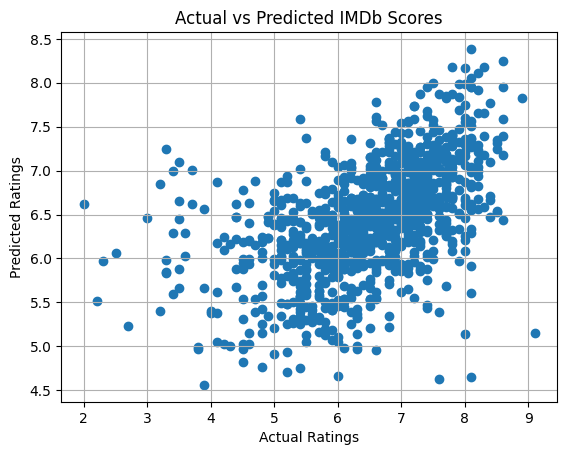

In [10]:
# 10. visualize predictions
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted IMDb Scores")
plt.grid()
plt.show()

In [11]:
# 11. Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances:\n", feature_importance_df)



Feature Importances:
          Feature  Importance
0       duration    0.223404
4         genres    0.174519
3     title_year    0.165343
2          gross    0.161927
5  director_name    0.138599
1         budget    0.136208


In [13]:
# 12. save the model and encoders for future use
output = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

output.to_csv("movie_predictions.csv", index=False)
print("\n✅ Task 4 Completed Successfully!")


✅ Task 4 Completed Successfully!
